# Estanque Cilíndrico — Análisis Sísmico según API650 y NCh2369:2025


In [1]:
import handcalcs.render
from handcalcs import render
handcalcs.set_option("display_precision", 3)
handcalcs.set_option("decimal_separator", ",")
from handcalcs.decorator import handcalc

from math import pi, sqrt, sin, cos, tan, atan, tanh, cosh, sinh
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
import matplotlib.patches as mpatches

import forallpeople
forallpeople.environment('structural', top_level=True)

# Configuración para gráficos export-ready
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 13

# 1. Parámetros de Entrada

In [2]:
%%render params
# Geometría
r_tanque = 6 * m
e_pared = 5 * mm
h_pared = 11.4 * m
gamma_acero = 78.5 * kN / m**3
gamma_agua = 9.81 * kN / m**3
grav = 9.81 * m / s**2
e_fondo = 10 * mm
h_liq = 8.84 * m
h_total = 11.4 * m

<IPython.core.display.Latex object>

# 2. Cálculo de Masas

In [3]:
%%render symbolic
PP_pared=(2*pi*r_tanque)*e_pared*h_pared*gamma_acero
M_pared = PP_pared / grav

PP_fondo = pi * r_tanque**2 * e_fondo * gamma_acero
M_fondo = PP_fondo / grav

V_liq = pi * r_tanque**2 * h_liq
PP_liq = V_liq * gamma_agua
M_liq = PP_liq / grav

PP_techo = 50 * kN
M_techo = PP_techo / grav

<IPython.core.display.Latex object>

In [4]:
%%render params 1
PP_pared=(2*pi*r_tanque)*e_pared*h_pared*gamma_acero
M_pared = PP_pared / grav

PP_fondo = pi * r_tanque**2 * e_fondo * gamma_acero
M_fondo = PP_fondo / grav

V_liq = pi * r_tanque**2 * h_liq
PP_liq = V_liq * gamma_agua
M_liq = PP_liq / grav

PP_techo = 50 * kN
M_techo = PP_techo / grav

<IPython.core.display.Latex object>

# 3. Modelo de Masas y Alturas Impulsiva y Convectiva

In [5]:
@handcalc(jupyter_display=True)
def func_m_i(D, h_liq, M_liq):
    m_i = (np.tanh(0.866 * D / h_liq) / (0.866 * D / h_liq))*M_liq
    return m_i

@handcalc(jupyter_display=True)
def func_m_c(D, h_liq, M_liq):
    m_c = 0.23*np.tanh(3.68*h_liq/D)/(h_liq/D)*M_liq
    return m_c

@handcalc(jupyter_display=True)
def func_h_i(D, h_variable, h_liq):
    h_i = h_liq*np.where(h_variable/D <= 0.75, 0.375, 0.5-0.09375/(h_variable/D))
    return h_i

@handcalc(jupyter_display=True)
def func_h_c(D, h_variable, h_liq):
    h_c = h_liq*(1-(np.cosh(3.68*h_variable/D)-1)/(3.68*h_variable/D*np.sinh(3.68*h_variable/D)))
    return h_c

@handcalc(jupyter_display=True)
def func_h_prime_i(D, h_variable, h_liq):
    h_prime_i = h_liq * np.where(h_variable/D <= 1.33, (0.866*D/h_variable)/(2*np.tanh(0.866*D/h_variable)) - 0.125, 0.45)
    return h_prime_i

@handcalc(jupyter_display=True)
def func_h_prime_c(D, h_variable, h_liq):
    h_prime_c = h_liq*(1-(np.cosh(3.68*h_variable/D)-2.01)/(3.68*h_variable/D*np.sinh(3.68*h_variable/D)))
    return h_prime_c

In [6]:
%%render 1
D = 2 * r_tanque
rel = h_liq / D

<IPython.core.display.Latex object>

### Masa Impulsiva

$$
\begin{aligned}
m_{i} &= M_{liq} \cdot \left( \frac{ \tanh \left( 0{,}866 \cdot \frac{ D }{ h_{liq} } \right) }{ 0{,}866 \cdot \frac{ D }{ h_{liq} } } \right)
\end{aligned}
$$

In [7]:
%%render params
m_i = func_m_i(D, h_liq, M_liq)

<IPython.core.display.Latex object>

### Masa Convectiva

$$
\begin{aligned}
m_{c} &= M_{liq} \cdot \left( 0{,}23 \cdot \frac{ \tanh \left( 3{,}68 \cdot \frac{ h_{liq} }{ D } \right) }{ \frac{ h_{liq} }{ D } } \right)
\end{aligned}
$$

In [8]:
%%render params
m_c = func_m_c(D, h_liq, M_liq)


<IPython.core.display.Latex object>

### Altura Masa Impulsiva sobre nivel base sin considerar presión en fondo 

$$
\begin{aligned}
h_i = h_{liq} \begin{cases} 0.375 & \text{si} \frac{h_{liq}}{D} \leq 0.75 \\ 0.5 - \frac{0.09375}{\frac{h_{liq}}{D}} & \text{si } \frac{h_{liq}}{D} > 0.75 \end{cases}
\end{aligned}
$$

In [9]:
%%render params
h_i = func_h_i(D, h_liq, h_liq)

<IPython.core.display.Latex object>

### Altura Masa Convectiva sobre nivel base sin considerar presión en fondo

$$
\begin{aligned}
h_{c} &= h_{liq} \cdot \left( 1 - \frac{ \cosh \left( 3{,}68 \cdot \frac{ h_{liq} }{ D } \right) - 1 }{ 3{,}68 \cdot \frac{ h_{liq} }{ D } \cdot \sinh \left( 3{,}68 \cdot \frac{ h_{liq} }{ D } \right) } \right)
\end{aligned}
$$

In [10]:
%%render params
h_c = func_h_c(D, h_liq, h_liq)


<IPython.core.display.Latex object>

### Altura Masa Impulsiva sobre nivel base considerando presión en fondo

$$
\begin{aligned}
h^*_i = \begin{cases} h_{liq} \cdot \left(\frac{0.866 \cdot D / h_{liq}}{2 \cdot \tanh(0.866 \cdot D / h_{liq})} - 0.125\right) & \text{si } \frac{h_{liq}}{D} \leq 1.33 \\ 0.45 & \text{si } \frac{h_{liq}}{D} > 1.33 \end{cases}
\end{aligned}
$$

In [11]:
%%render params
h_prime_i = func_h_prime_i(D, h_liq, h_liq)



<IPython.core.display.Latex object>

### Altura Masa Convectiva sobre nivel base considerando presión en fondo

$$
\begin{aligned}
h'_{c} &= h_{liq} \cdot \left( 1 - \frac{ \cosh \left( 3{,}68 \cdot \frac{ h_{liq} }{ D } \right) - 2{,}01 }{ 3{,}68 \cdot \frac{ h_{liq} }{ D } \cdot \sinh \left( 3{,}68 \cdot \frac{ h_{liq} }{ D } \right) } \right)
\end{aligned}
$$

In [12]:
%%render params
h_prime_c = func_h_prime_c(D, h_liq, h_liq)

<IPython.core.display.Latex object>

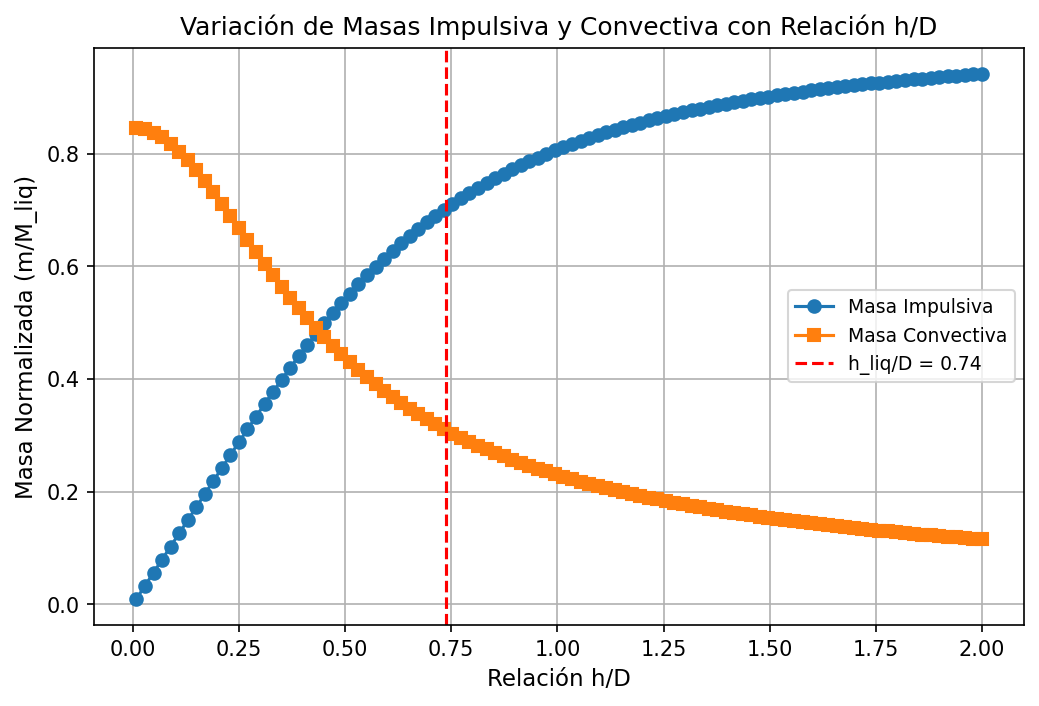

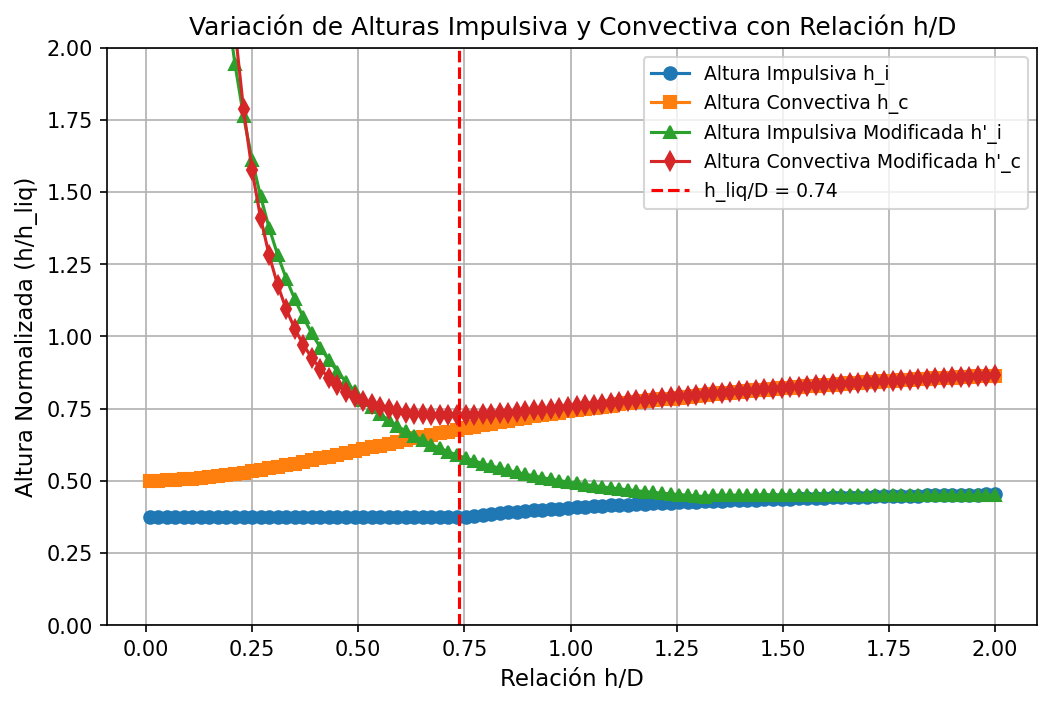

In [13]:
#Gráficos de variación de masas y alturas con la relación h/D
#Variación de masas impulsiva y convectiva con la relación h/D
#D es fijo, h_liq varía
h_evaluada = np.linspace(0.1, 2*D.value, 100) # Evaluar las funciones para cada altura
m_i_evaluada = func_m_i.__wrapped__(D.value, h_evaluada, M_liq.value)
m_c_evaluada = func_m_c.__wrapped__(D.value, h_evaluada, M_liq.value)

fig, ax = plt.subplots(1 ,1, figsize=(8, 5))
plt.plot(h_evaluada/D.value, m_i_evaluada/M_liq.value, label='Masa Impulsiva', marker='o')
plt.plot(h_evaluada/D.value, m_c_evaluada/M_liq.value, label='Masa Convectiva', marker='s')
ax.set_xlabel('Relación h/D')
ax.set_ylabel('Masa Normalizada (m/M_liq)')
ax.set_title('Variación de Masas Impulsiva y Convectiva con Relación h/D')

#agregar linea vertical con relacion h_liq/D actual
plt.axvline(x=h_liq.value/D.value, color='red', linestyle='--', label=f'h_liq/D = {h_liq.value/D.value:.2f}')
ax.legend()
ax.grid()
plt.show()

#Variacion de alturas impulsiva y convectiva con la relación h/D
h_i_evaluada = func_h_i.__wrapped__(D.value, h_evaluada, h_liq.value)
h_c_evaluada = func_h_c.__wrapped__(D.value, h_evaluada, h_liq.value)
h_prime_i_evaluada = func_h_prime_i.__wrapped__(D.value, h_evaluada, h_liq.value)
h_prime_c_evaluada = func_h_prime_c.__wrapped__(D.value, h_evaluada, h_liq.value)
fig, ax = plt.subplots(1 ,1, figsize=(8, 5))

plt.plot(h_evaluada/D.value, h_i_evaluada/h_liq.value, label='Altura Impulsiva h_i', marker='o')
plt.plot(h_evaluada/D.value, h_c_evaluada/h_liq.value, label='Altura Convectiva h_c', marker='s')
plt.plot(h_evaluada/D.value, h_prime_i_evaluada/h_liq.value, label='Altura Impulsiva Modificada h\'_i', marker='^')
plt.plot(h_evaluada/D.value, h_prime_c_evaluada/h_liq.value, label='Altura Convectiva Modificada h\'_c', marker='d')

ax.set_xlabel('Relación h/D')
ax.set_ylabel('Altura Normalizada (h/h_liq)')
ax.set_title('Variación de Alturas Impulsiva y Convectiva con Relación h/D')
#agregar linea vertical con relacion h_liq/D actual limite de eje vertical a 2.0 para mejor visualización
plt.axvline(x=h_liq.value/D.value, color='red', linestyle='--', label=f'h_liq/D = {h_liq.value/D.value:.2f}')
ax.set_ylim(0, 2.0)
ax.legend()
ax.grid()
plt.show()

# 4. Análisis Sísmico — Periodos Fundamentales

In [14]:
%%render
E = 200 * GPa

<IPython.core.display.Latex object>

In [15]:
%%render short 2
C_i = (1/(sqrt(h_liq/D)*(0.46-0.3*h_liq/D+0.067*(h_liq/D)**2)))
T_i = (C_i*h_liq*sqrt(gamma_agua/grav))/(sqrt(e_pared/D)*sqrt(E)*1000) * s / m

<IPython.core.display.Latex object>

In [16]:
%%render short 2
C_c = (2*pi)/sqrt(3.68*tanh(3.68*h_liq/D))
T_c = (C_c*sqrt(D/grav)) *s

<IPython.core.display.Latex object>

# 5. Parámetros Sísmicos NCh2369:2025

11.2.1.6: En estanques bajos se debe usar un valor máximo R=4 para el factor de modificación de respuesta impulsiva en el caso en que el estanque esté mecánicamente anclado contra el volcamiento. La razón de amortiguamiento asociada a la respuesta impulsiva debe ser $\xi_i=2\%$

11.2.1.7: En estanques bajos, los parámetros de diseño asociados a la respuesta convectiva deben ser R=1.5 y $\xi_c=0.5$

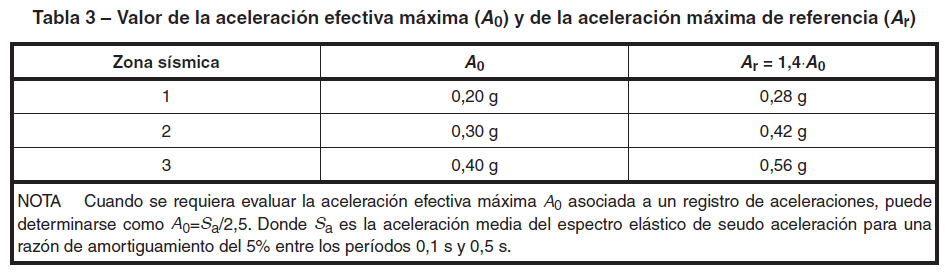



In [17]:
%%render params
I = 1
R_i = 4
xi_i = 2/100 #$\%$
R_c = 1.5
xi_c = 0.5/100 #$\%$
A_r = 0.42*grav

<IPython.core.display.Latex object>

Parámetros del Tipo de Suelo B

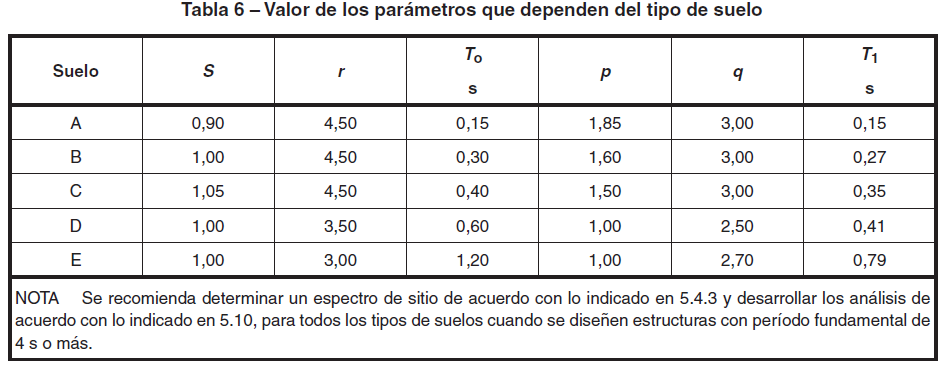

In [18]:
%%render params 1
S = 1
r = 4.5
T_0 = 0.3 * s
p = 1.6
q = 3.00
T_1 = 0.27 * s

<IPython.core.display.Latex object>

### Aceleración espectral impulsiva

Se considera que la masa impulsiva se mueve rigidamente con el estanque, por lo que se considera $S_{ah}$ espectral maximo normativo.

In [19]:
%%render 2
S_ai = (2.75*(I*A_r*S)/(R_i+1)*(0.05/xi_i)**0.4)*1/grav

<IPython.core.display.Latex object>

### Aceleración espectral convectiva

Según API650, sección E.4.2.4 "Site-Specific MCE Ground Motions", establece que para un amortiguamiento $xi=0.5\%$, el comportamiento convectivo debe considerar un factor de 1.5 veces el valor espectral considerando $xi=5%$.
Por lo anterior, en el ajuste del espectro de diseño, se asume:

$
(\frac{0.05}{\xi})^{0.4}=1.5
$

In [20]:
%%render 2
C_r = 0.16 * R_c
T_1

if R_c == 1: R_prime = 1
elif (T_c) >= (C_r * T_1): R_prime = R_c
else: R_prime = 1.5 + (R_c - 1.5) * (T_c) / (C_r * T_1)

S_ac = (A_r * S * ((1+r*(T_c/T_0)**p)/(1+(T_c/T_0)**q)))*((I/R_prime)*1.5)*1/grav

<IPython.core.display.Latex object>

El valor de $S_a$ para la respuesta convectiva no debe ser menor que $0.1 \cdot I \cdot A_r \cdot S / g $

In [21]:
%%render 2
S_a_cmin = 0.1*I*A_r*S/grav

<IPython.core.display.Latex object>

# 6. Fuerzas y Momentos Sísmicos

## 6.1 Corte Basal

In [22]:
%%render 2
V_i = S_ai*(m_i+M_pared+M_techo)*grav
V_c = S_ac*m_c * grav
V = (V_i**2 + V_c**2)**0.5
check_V = V / ((m_i+m_c)*grav)

<IPython.core.display.Latex object>

## 6.2 Momento Fondo Muro

In [23]:
%%render 2
M_i = S_ai*(m_i*h_i+M_pared*h_pared/2+M_techo*h_total)*grav
M_c = S_ac*(m_c*h_c)*grav
M = (M_i**2 + M_c**2)**0.5

<IPython.core.display.Latex object>

## 6.3 Momento Volcante

In [24]:
%%render 2
M_prime_i = S_ai*(m_i*h_prime_i+M_pared*h_pared/2+M_techo*h_total+M_fondo*e_fondo/2)*grav
M_prime_c = S_ac*(m_c*h_prime_c)*grav
M_prime = (M_prime_i**2 + M_prime_c**2)**0.5

<IPython.core.display.Latex object>

# 7. Presiones Hidrodinámicas

## 7.1 Presión en Muros - Impulsivo
Máximo ocurre en la base y = 0

In [25]:
@handcalc(jupyter_display=True)
def Q_iw(y, h_liq, D):
    Q_iw = 0.866 * (1 - (y / h_liq)**2) * np.tanh(0.866 * D / h_liq)
    return Q_iw
# Calcular Q_iw en la base
Q_iw_max = Q_iw(0, h_liq.value, D.value)

<IPython.core.display.Latex object>

In [26]:
%%render 2
p_iw = Q_iw_max * gamma_agua * h_liq * S_ai

<IPython.core.display.Latex object>

## 7.2 Presión en Fondo - Impulsivo

Máximo ocurre en el perimetro de la base x = D/2

In [27]:
@handcalc(jupyter_display=True)
def Q_ib(x, h_liq, D):
    Q_ib = 0.866 * (np.sinh(0.866*2*x/h_liq))/(np.cosh(0.866*D/h_liq))
    return Q_ib

# Calcular Q_ib en borde
Q_ib_max = Q_ib(D.value/2, h_liq.value, D.value)

<IPython.core.display.Latex object>

In [28]:
%%render 2
p_ib = Q_ib_max * gamma_agua * h_liq * S_ai

<IPython.core.display.Latex object>

## 7.3 Presión en Muros - Convectivo

Máximo ocurre en el extremo superior del liquido $y=h_{liq}$

In [29]:
@handcalc(jupyter_display=True)
def Q_cw(y, h_liq, D):
    Q_cw = 0.5625*(np.cosh(3.674*y/D))/(np.cosh(3.674*h_liq/D))
    return Q_cw

# Calcular Q_cw en superficie
Q_cw_max = Q_cw(h_liq.value, h_liq.value, D.value)

<IPython.core.display.Latex object>

In [30]:
%%render 2
p_cw = Q_cw_max * gamma_agua * h_liq * S_ac

<IPython.core.display.Latex object>

## 7.4 Presión en Fondo - Convectivo
Máximo ocurre en el perimetro de la base x = D/2

In [31]:
@handcalc(jupyter_display=True)
def Q_cb(x, h_liq, D):
    Q_cb = 1.125*((x/D)-(4/3)*(x/D)**3) / np.cosh(3.674*h_liq/D)
    return Q_cb

# Calcular Q_cb en borde
Q_cb_max = Q_cb(D.value/2, h_liq.value, D.value)

<IPython.core.display.Latex object>

In [32]:
%%render 2
p_cb = Q_cb_max * gamma_agua * h_liq * S_ac

<IPython.core.display.Latex object>

## 7.5 Presión Lineal Equivalente en muros

### Impulsiva

In [33]:
%%render 2
q_i = (S_ai*m_i*grav)/(pi * D / 2)
a_i = (q_i)/((h_liq)**2) * (4*h_liq - 6*h_i)
b_i = (q_i)/((h_liq)**2) * (6*h_i - 2*h_liq)

<IPython.core.display.Latex object>

### Convectiva

In [34]:
%%render 2
q_c = (S_ac*m_c*grav)/(pi * D / 2)
a_c = (q_c)/((h_liq)**2) * (4*h_liq - 6*h_c)
b_c = (q_c)/((h_liq)**2) * (6*h_c - 2*h_liq)

<IPython.core.display.Latex object>

## 7.6 Presión por Inercia de Muro

In [35]:
%%render
p_ww = S_ai * e_pared * gamma_acero

<IPython.core.display.Latex object>

## 7.7 Presión por Acción Sísmica Vertical

In [36]:
%%render params 2

R_v = 2
T_v = (0.3*s)
xi_v = 2/100 #$\%$

<IPython.core.display.Latex object>

In [37]:
%%render 2

S_av = ((I)/(R_v)*(0.05/xi_v)**0.4)*(0.7*A_r*S*((1+r*(1.7*T_v/T_0)**p)/(1+(1.7*T_v/T_0)**q)))*1/grav

p_v = S_av * gamma_agua * h_liq

<IPython.core.display.Latex object>

## 7.8 Presión Hidrodinámica Máxima Combinada (SRSS)

In [38]:
%%render
p = ((p_iw + p_ww)**2 + p_cw**2 + p_v**2)**0.5
p_estatico = (gamma_agua * h_liq)
rel_presion = p / p_estatico

<IPython.core.display.Latex object>

In [39]:
print(f"La presión hidrodinámica máxima {p.value/1000:.2f} kPa es aproximadamente un {rel_presion:.2f}%. de la presión hidrostática en el fondo {p_estatico.value/1000:.2f} kPa.")

La presión hidrodinámica máxima 41.52 kPa es aproximadamente un 0.48%. de la presión hidrostática en el fondo 86.72 kPa.


# 8. Altura de Ola y Anclaje

In [40]:
%%render 2
d_max = S_ac * 2.5 * D / 2

<IPython.core.display.Latex object>

In [41]:
# Verificación de requerimiento de anclaje
check_anclaje = ("SÍ REQUIERE" if h_liq/D >= 1/float(S_ai) else "NO REQUIERE")
print(f"¿Requiere anclaje?: {check_anclaje}")
print(f"Relación h/D = {h_liq/D:.3f}")
print(f"Criterio: h/D ≥ 1/S_ai = {1/float(S_ai):.3f}")

¿Requiere anclaje?: NO REQUIERE
Relación h/D = 0.737
Criterio: h/D ≥ 1/S_ai = 3.001


---
# 9. VISUALIZACIONES Y ANÁLISIS DE RESULTADOS

## 9.1 Distribuciones de Presión Hidrodinámica sobre Muro y Fondo

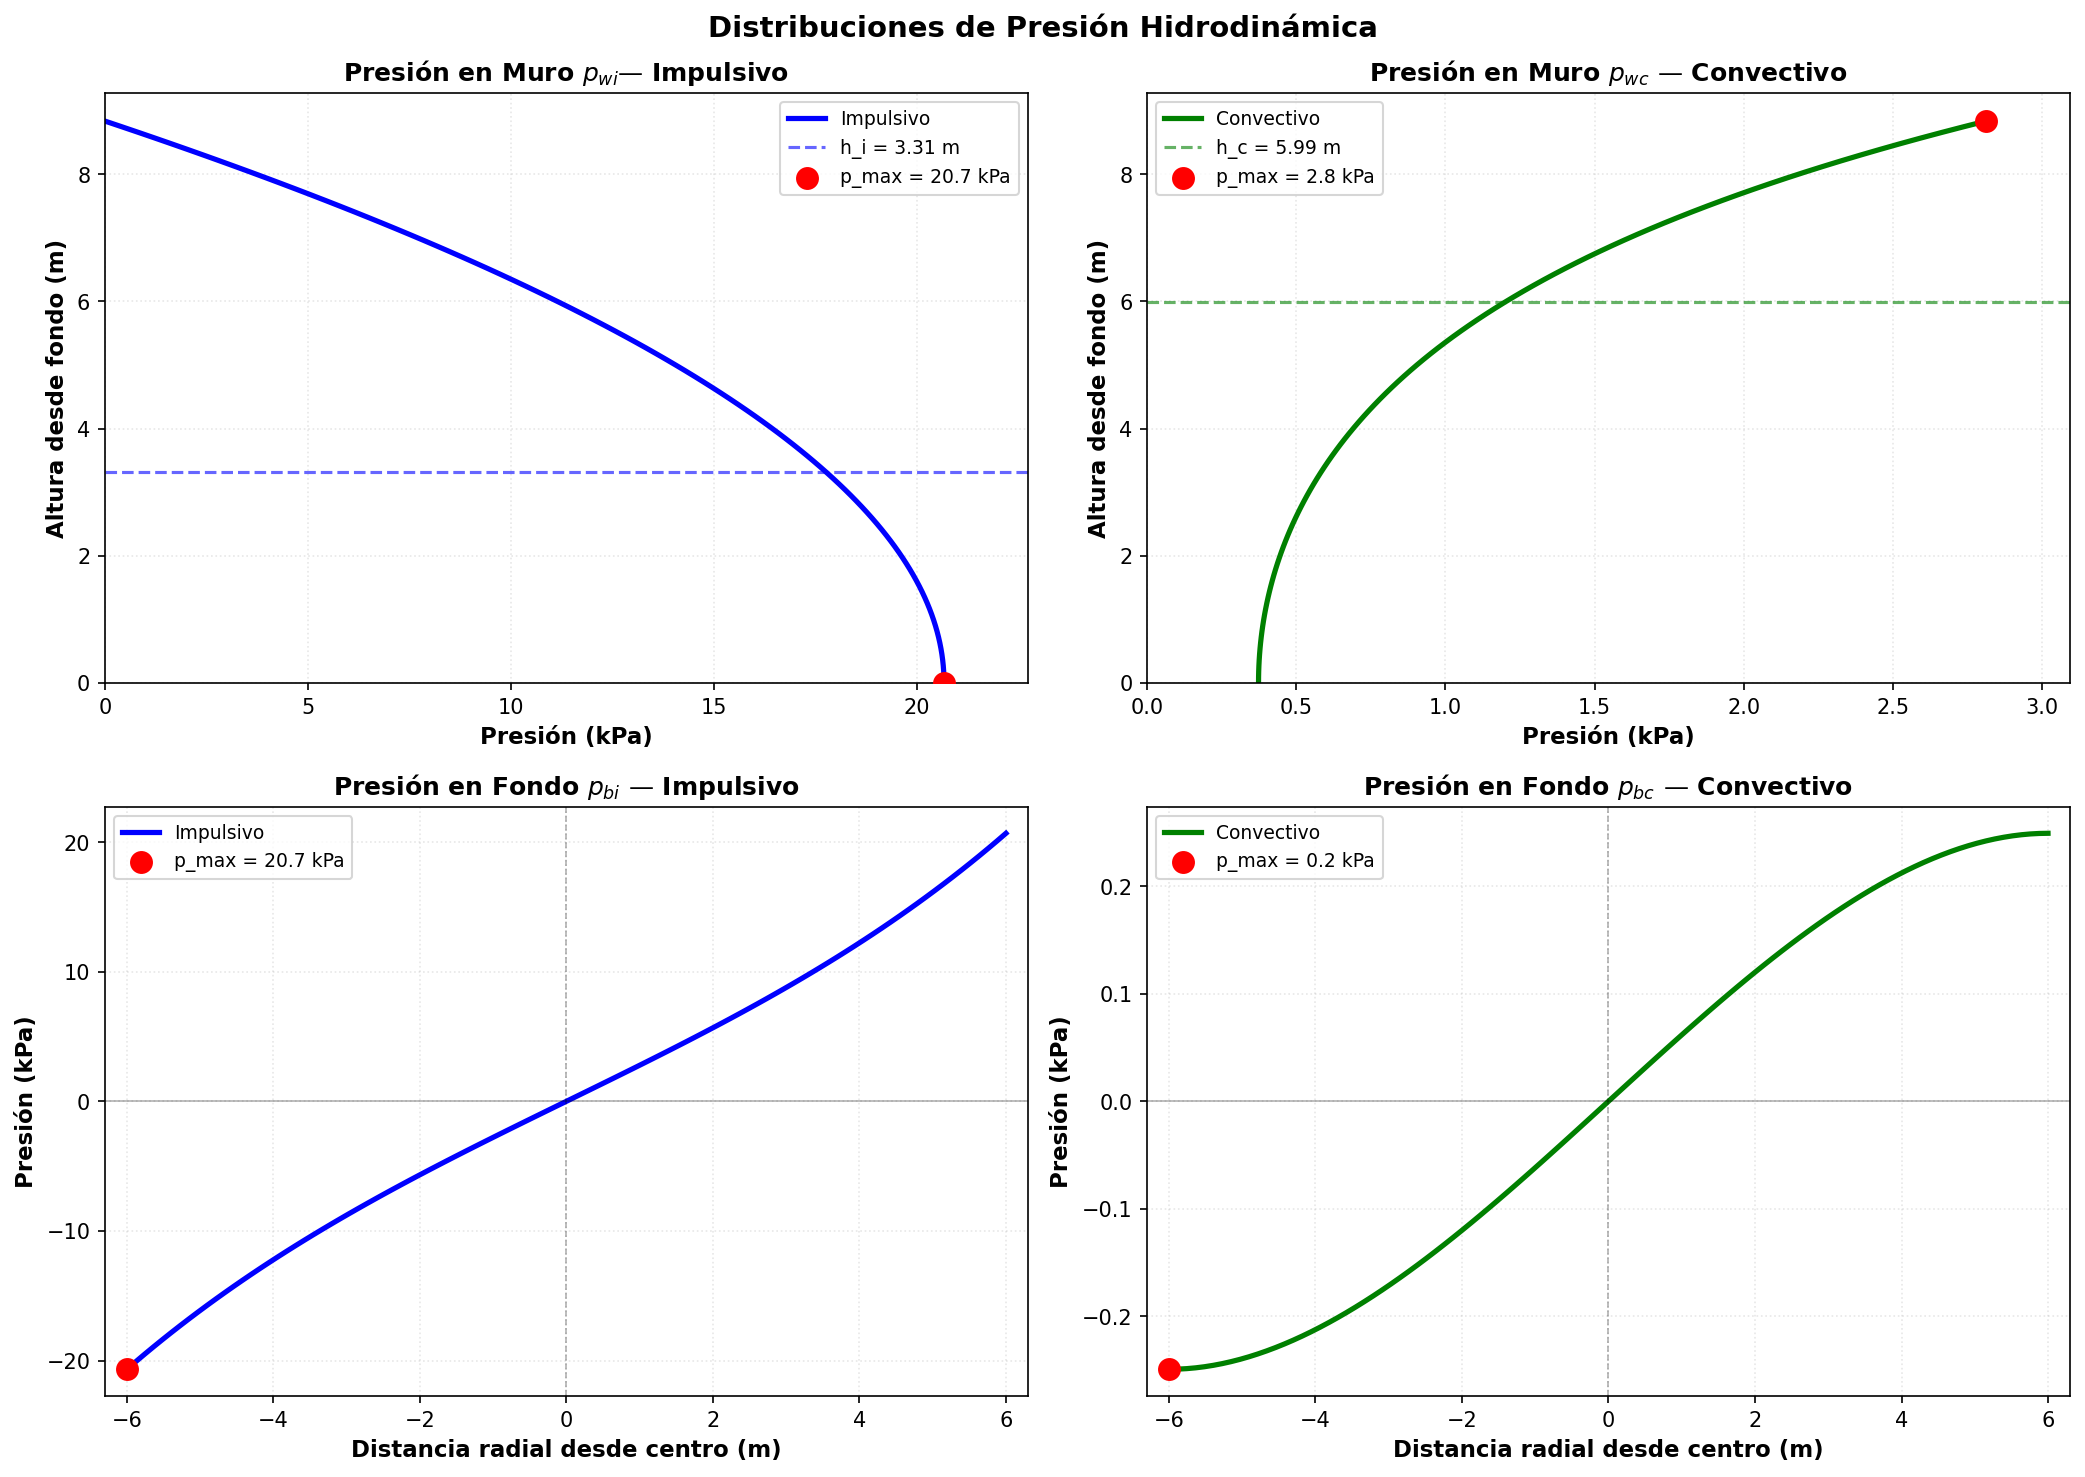

In [42]:
# Crear figura con 4 subplots para presiones

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribuciones de Presión Hidrodinámica', fontsize=14, fontweight='bold')

# 1. Presión en Muro - Impulsivo
y_wall = np.linspace(0, h_liq.value, 100)
Q_iw_dist = Q_iw.__wrapped__(y_wall, h_liq.value, D.value)
p_iw_dist = Q_iw_dist * float(gamma_agua) * h_liq.value * float(S_ai)  # en kPa

axes[0,0].plot(p_iw_dist, y_wall, 'b-', linewidth=2.5, label='Impulsivo')
axes[0,0].axhline(y=float(h_i), color='b', linestyle='--', alpha=0.6, linewidth=1.5, label=f'h_i = {float(h_i):.2f} m')
axes[0,0].scatter([p_iw_dist[0]], [0], color='red', s=100, zorder=5, label=f'p_max = {p_iw_dist[0]:.1f} kPa')
axes[0,0].set_xlabel('Presión (kPa)', fontweight='bold')
axes[0,0].set_ylabel('Altura desde fondo (m)', fontweight='bold')
axes[0,0].set_title('Presión en Muro $p_{wi}$— Impulsivo', fontweight='bold')
axes[0,0].grid(True, alpha=0.3, linestyle=':')
axes[0,0].legend(loc='best')
axes[0,0].set_ylim([0, h_liq.value*1.05])
axes[0,0].set_xlim([0, max(p_iw_dist)*1.1])

# 2. Presión en Muro - Convectivo
Q_cw_dist = Q_cw.__wrapped__(y_wall, h_liq.value, D.value)
p_cw_dist = Q_cw_dist * float(gamma_agua) * h_liq.value * float(S_ac)  # en kPa

axes[0,1].plot(p_cw_dist, y_wall, 'g-', linewidth=2.5, label='Convectivo')
axes[0,1].axhline(y=float(h_c), color='g', linestyle='--', alpha=0.6, linewidth=1.5, label=f'h_c = {float(h_c):.2f} m')
axes[0,1].scatter([p_cw_dist[-1]], [h_liq.value], color='red', s=100, zorder=5, label=f'p_max = {p_cw_dist[-1]:.1f} kPa')
axes[0,1].set_xlabel('Presión (kPa)', fontweight='bold')
axes[0,1].set_ylabel('Altura desde fondo (m)', fontweight='bold')
axes[0,1].set_title('Presión en Muro $p_{wc}$ — Convectivo', fontweight='bold')
axes[0,1].grid(True, alpha=0.3, linestyle=':')
axes[0,1].legend(loc='best')
axes[0,1].set_ylim([0, h_liq.value*1.05])
axes[0,1].set_xlim([0, max(p_cw_dist)*1.1])

# 3. Presión en Fondo - Impulsivo
x_bottom = np.linspace(-D.value/2, D.value/2, 100)
Q_ib_dist = Q_ib.__wrapped__(x_bottom, h_liq.value, D.value)
p_ib_dist = Q_ib_dist * float(gamma_agua) * h_liq.value * float(S_ai)  # en kPa

axes[1,0].plot(x_bottom, p_ib_dist, 'b-', linewidth=2.5, label='Impulsivo')
axes[1,0].axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
axes[1,0].axvline(x=0, color='k', linestyle='--', alpha=0.3, linewidth=0.8)
idx_max = np.argmax(np.abs(p_ib_dist))
axes[1,0].scatter([x_bottom[idx_max]], [p_ib_dist[idx_max]], color='red', s=100, zorder=5, label=f'p_max = {abs(p_ib_dist[idx_max]):.1f} kPa')
axes[1,0].set_xlabel('Distancia radial desde centro (m)', fontweight='bold')
axes[1,0].set_ylabel('Presión (kPa)', fontweight='bold')
axes[1,0].set_title('Presión en Fondo $p_{bi}$ — Impulsivo', fontweight='bold')
axes[1,0].grid(True, alpha=0.3, linestyle=':')
axes[1,0].legend(loc='best')
axes[1,0].set_xlim([-D.value/2*1.05, D.value/2*1.05])

# 4. Presión en Fondo - Convectivo
Q_cb_dist = Q_cb.__wrapped__(x_bottom, h_liq.value, D.value)
p_cb_dist = Q_cb_dist * float(gamma_agua) * h_liq.value * float(S_ac)  # en kPa

axes[1,1].plot(x_bottom, p_cb_dist, 'g-', linewidth=2.5, label='Convectivo')
axes[1,1].axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
axes[1,1].axvline(x=0, color='k', linestyle='--', alpha=0.3, linewidth=0.8)
idx_max = np.argmax(np.abs(p_cb_dist))
axes[1,1].scatter([x_bottom[idx_max]], [p_cb_dist[idx_max]], color='red', s=100, zorder=5, label=f'p_max = {abs(p_cb_dist[idx_max]):.1f} kPa')
axes[1,1].set_xlabel('Distancia radial desde centro (m)', fontweight='bold')
axes[1,1].set_ylabel('Presión (kPa)', fontweight='bold')
axes[1,1].set_title('Presión en Fondo $p_{bc}$ — Convectivo', fontweight='bold')
axes[1,1].grid(True, alpha=0.3, linestyle=':')
axes[1,1].legend(loc='best')
axes[1,1].set_xlim([-D.value/2*1.05, D.value/2*1.05])

plt.tight_layout()
plt.show()

## 9.2 Comparación Impulsivo vs. Convectivo

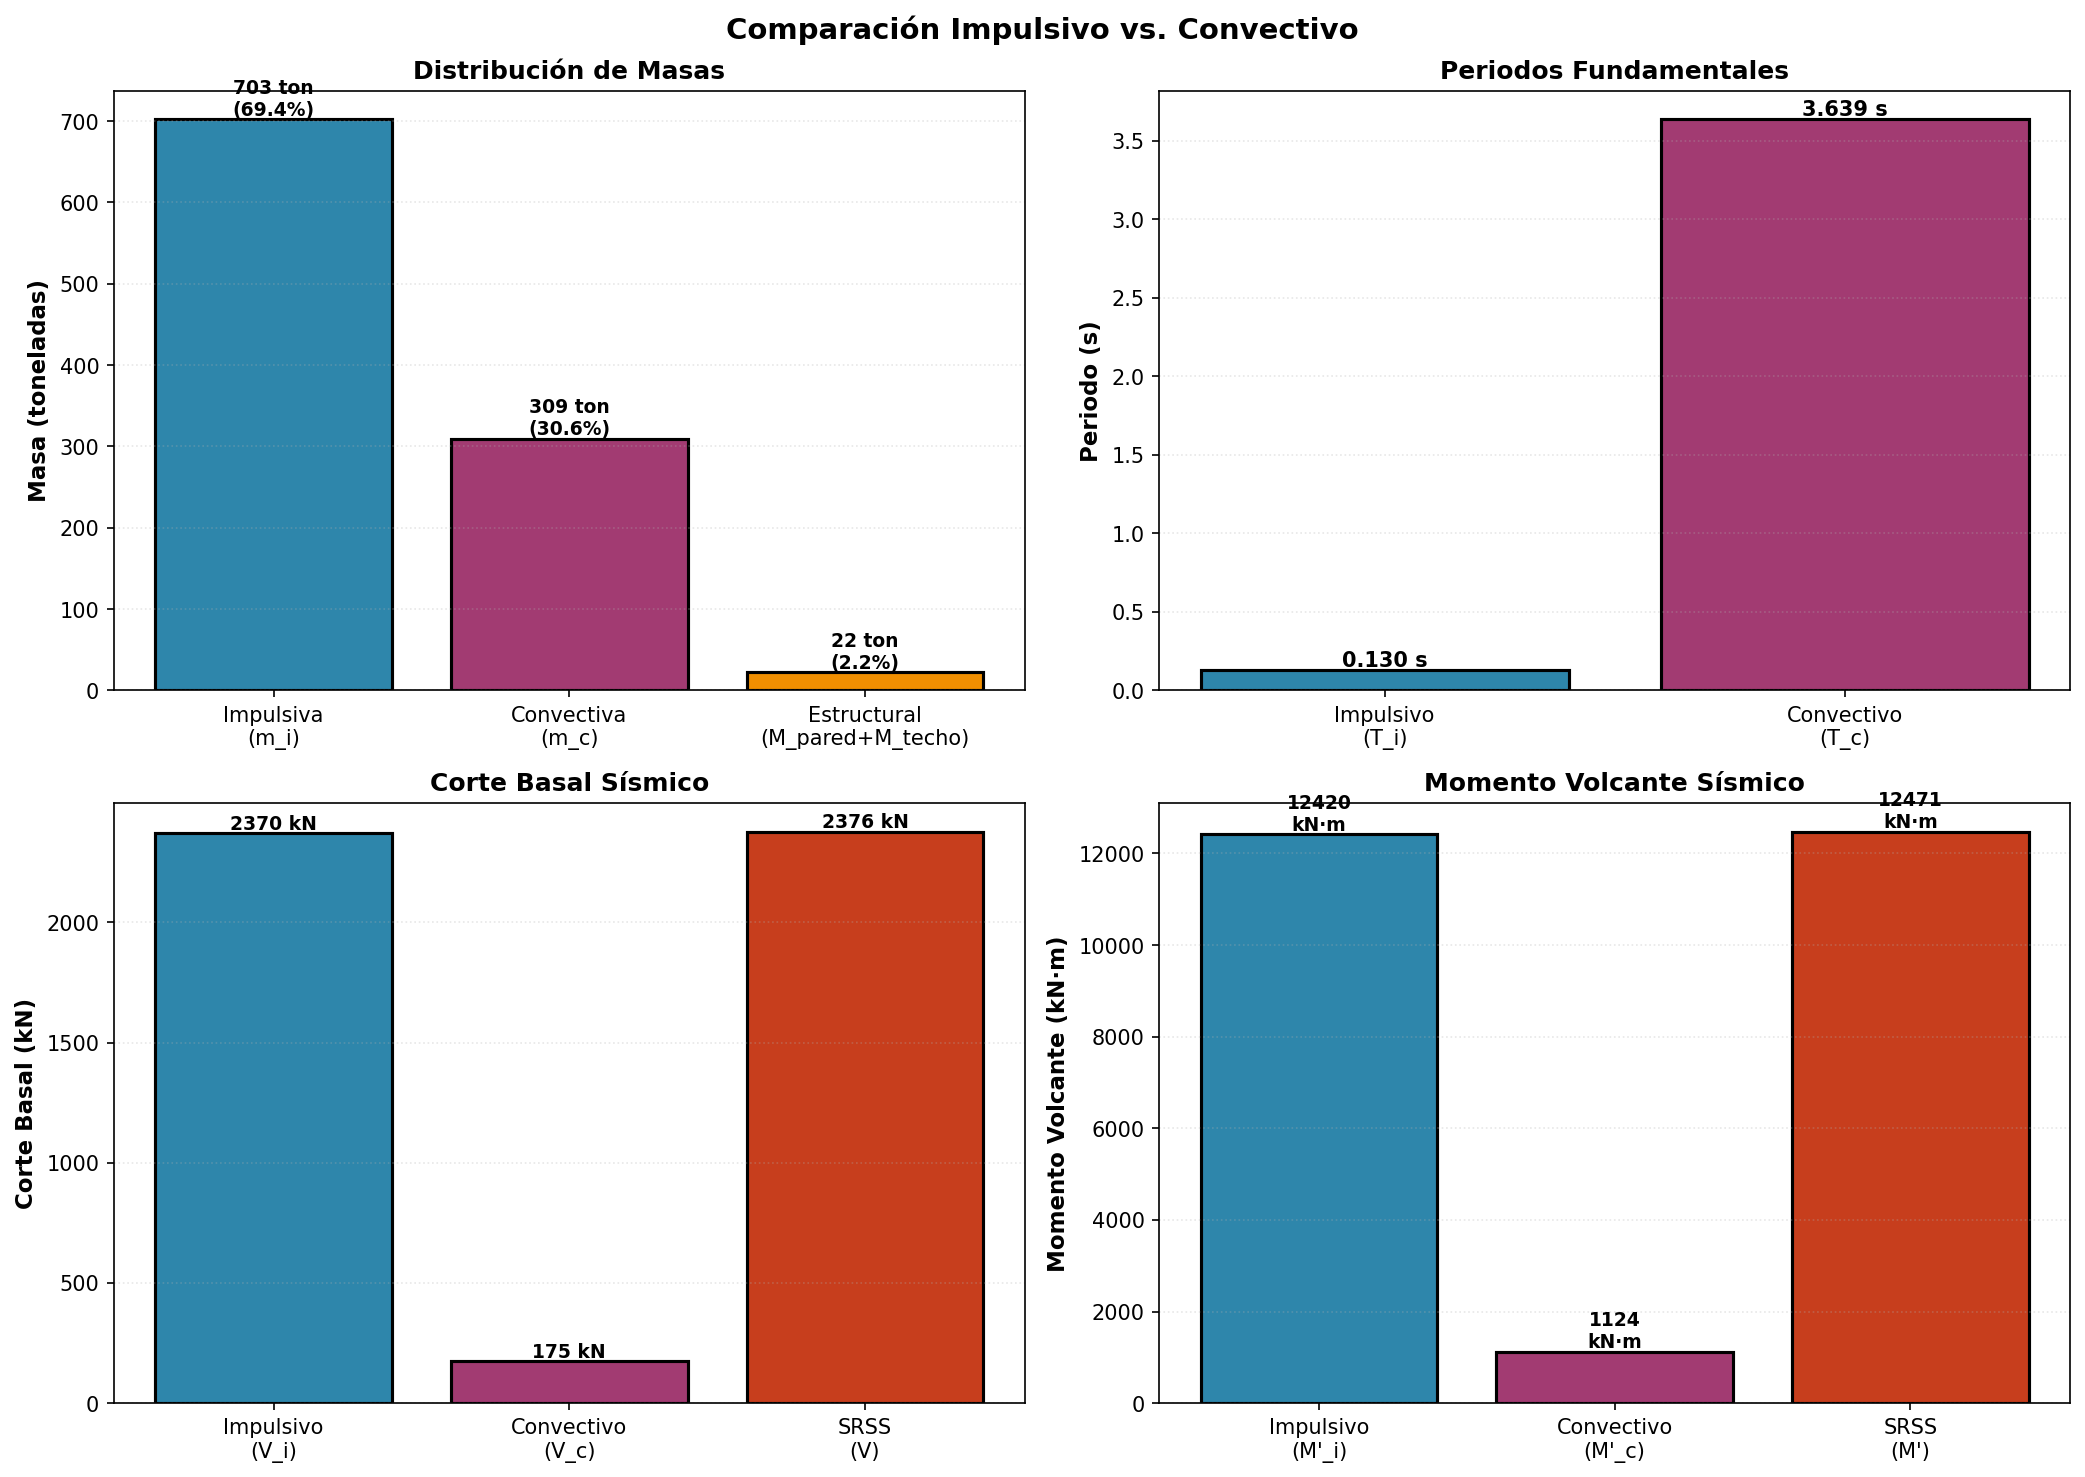

In [43]:
# Crear figura comparativa
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparación Impulsivo vs. Convectivo', fontsize=14, fontweight='bold')

# 1. Comparación de Masas
masas_labels = ['Impulsiva\n(m_i)', 'Convectiva\n(m_c)', 'Estructural\n(M_pared+M_techo)']
masas_values = [m_i.value/1000, m_c.value/1000, (M_pared.value + M_techo.value)/1000]  # Convertir a toneladas
colors_masa = ['#2E86AB', '#A23B72', '#F18F01']

bars1 = axes[0,0].bar(masas_labels, masas_values, color=colors_masa, edgecolor='black', linewidth=1.5)
axes[0,0].set_ylabel('Masa (toneladas)', fontweight='bold')
axes[0,0].set_title('Distribución de Masas', fontweight='bold')
axes[0,0].grid(True, axis='y', alpha=0.3, linestyle=':')
for i, (bar, val) in enumerate(zip(bars1, masas_values)):
    height = bar.get_height()
    axes[0,0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.0f} ton\n({val/(m_i.value/1000+m_c.value/1000)*100:.1f}%)',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Comparación de Periodos
periodos_labels = ['Impulsivo\n(T_i)', 'Convectivo\n(T_c)']
periodos_values = [T_i.value, T_c.value]
colors_periodo = ['#2E86AB', '#A23B72']

bars2 = axes[0,1].bar(periodos_labels, periodos_values, color=colors_periodo, edgecolor='black', linewidth=1.5)
axes[0,1].set_ylabel('Periodo (s)', fontweight='bold')
axes[0,1].set_title('Periodos Fundamentales', fontweight='bold')
axes[0,1].grid(True, axis='y', alpha=0.3, linestyle=':')
for bar, val in zip(bars2, periodos_values):
    height = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.3f} s',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Comparación de Corte Basal
corte_labels = ['Impulsivo\n(V_i)', 'Convectivo\n(V_c)', 'SRSS\n(V)']
corte_values = [V_i.value/1000, V_c.value/1000, V.value/1000]  # Convertir a kN
colors_corte = ['#2E86AB', '#A23B72', '#C73E1D']

bars3 = axes[1,0].bar(corte_labels, corte_values, color=colors_corte, edgecolor='black', linewidth=1.5)
axes[1,0].set_ylabel('Corte Basal (kN)', fontweight='bold')
axes[1,0].set_title('Corte Basal Sísmico', fontweight='bold')
axes[1,0].grid(True, axis='y', alpha=0.3, linestyle=':')
for bar, val in zip(bars3, corte_values):
    height = bar.get_height()
    axes[1,0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.0f} kN',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. Comparación de Momento Volcante
momento_labels = ['Impulsivo\n(M\'_i)', 'Convectivo\n(M\'_c)', 'SRSS\n(M\')']
momento_values = [M_prime_i.value/1000, M_prime_c.value/1000, M_prime.value/1000]  # Convertir a kN·m
colors_momento = ['#2E86AB', '#A23B72', '#C73E1D']

bars4 = axes[1,1].bar(momento_labels, momento_values, color=colors_momento, edgecolor='black', linewidth=1.5)
axes[1,1].set_ylabel('Momento Volcante (kN·m)', fontweight='bold')
axes[1,1].set_title('Momento Volcante Sísmico', fontweight='bold')
axes[1,1].grid(True, axis='y', alpha=0.3, linestyle=':')
for bar, val in zip(bars4, momento_values):
    height = bar.get_height()
    axes[1,1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.0f}\nkN·m',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
# 10. DASHBOARD EJECUTIVO DE RESULTADOS

In [44]:
# Crear tabla resumen ejecutiva
print("="*90)
print(" "*25 + "RESUMEN DE RESULTADOS")
print("="*90)
print("\n PROYECTO: Estanque Cilíndrico de Acero")
print(" NORMATIVAS: API650 + NCh2369:2025")
print("\n" + "="*90)

print("\n" + "─"*90)
print("1. GEOMETRÍA Y PROPIEDADES")
print("─"*90)
print(f"   • Diámetro (D):              {2*(r_tanque.value):>10.2f} m")
print(f"   • Altura total (h_total):    {(h_pared.value):>10.2f} m")
print(f"   • Altura líquido (h_liq):    {(h_liq.value):>10.2f} m")
print(f"   • Relación h/D:              {(h_liq.value)/(2*(r_tanque.value)):>10.3f}")
print(f"   • Espesor pared (e_pared):   {(e_pared.value)*1000:>10.1f} mm")
print(f"   • Espesor fondo (e_fondo):   {(e_fondo.value)*1000:>10.1f} mm")
print(f"   • Volumen líquido:           {(V_liq.value):>10.1f} m³")

print("\n" + "─"*90)
print("2. MASAS Y DISTRIBUCIÓN")
print("─"*90)
print(f"   • Masa líquido total:        {(M_liq.value/1000):>10.1f} ton")
print(f"       - Impulsiva (m_i):       {(m_i.value/1000):>10.1f} ton  ({(m_i.value)/(M_liq.value)*100:>5.1f}%)")
print(f"       - Convectiva (m_c):      {(m_c.value/1000):>10.1f} ton  ({(m_c.value)/(M_liq.value)*100:>5.1f}%)")
print(f"   • Masa pared:                {(M_pared.value/1000):>10.1f} ton")
print(f"   • Masa fondo:                {(M_fondo.value/1000):>10.1f} ton")
print(f"   • Masa techo:                {(M_techo.value/1000):>10.1f} ton")
print(f"   • Masa total:                {(M_liq.value+M_pared.value+M_fondo.value+M_techo.value)/1000:>10.1f} ton")

print("\n" + "─"*90)
print("3. ALTURAS DE APLICACIÓN DE FUERZAS")
print("─"*90)
print(f"   • Altura impulsiva (h_i):    {(h_i.value):>10.3f} m  (momento base)")
print(f"   • Altura convectiva (h_c):   {(h_c.value):>10.3f} m  (momento base)")
print(f"   • Altura impulsiva (h'_i):   {(h_prime_i.value):>10.3f} m  (momento volcante)")
print(f"   • Altura convectiva (h'_c):  {(h_prime_c.value):>10.3f} m  (momento volcante)")

print("\n" + "─"*90)
print("4. PARÁMETROS SÍSMICOS")
print("─"*90)
print(f"   • Aceleración de referencia: {(A_r)/(grav):>10.3f} g")
print(f"   • Factor importancia (I):    {(I):>10.1f}")
print(f"   • Factor de suelo (S):       {(S):>10.1f}")
print(f"   • R impulsivo (R_i):         {(R_i):>10.1f}")
print(f"   • R convectivo (R_c):        {(R_c):>10.1f}")
print(f"   • Amortiguamiento ξ_i:       {(xi_i)*100:>10.1f} %")
print(f"   • Amortiguamiento ξ_c:       {(xi_c)*100:>10.1f} %")

print("\n" + "─"*90)
print("5. PERIODOS FUNDAMENTALES")
print("─"*90)
print(f"   • Periodo impulsivo (T_i):   {(T_i.value):>10.3f} s")
print(f"   • Periodo convectivo (T_c):  {(T_c.value):>10.3f} s")

print("\n" + "─"*90)
print("6. ACELERACIONES ESPECTRALES")
print("─"*90)
print(f"   • S_ai (impulsiva):          {(S_ai):>10.3f} g")
print(f"   • S_ac (convectiva):         {(S_ac):>10.3f} g")
print(f"   • S_av (vertical):           {(S_av):>10.3f} g")

print("\n" + "─"*90)
print("7. FUERZAS SÍSMICAS")
print("─"*90)
print(f"   CORTE BASAL:")
print(f"   • V_i (impulsivo):           {(V_i.value/1000):>10.1f} kN")
print(f"   • V_c (convectivo):          {(V_c.value/1000):>10.1f} kN")
print(f"   • V (SRSS):                  {(V.value/1000):>10.1f} kN  ⚡")
print(f"   • Coef. sísmico equiv.:      {(check_V):>10.3f} g")

print("\n" + "─"*90)
print("8. MOMENTOS SÍSMICOS")
print("─"*90)
print(f"   MOMENTO BASE (fondo muro):")
print(f"   • M_i (impulsivo):           {(M_i.value/1000):>10.0f} kN·m")
print(f"   • M_c (convectivo):          {(M_c.value/1000):>10.0f} kN·m")
print(f"   • M (SRSS):                  {(M.value/1000):>10.0f} kN·m  ⚡")
print(f"")
print(f"   MOMENTO VOLCANTE:")
print(f"   • M'_i (impulsivo):          {(M_prime_i.value/1000):>10.0f} kN·m")
print(f"   • M'_c (convectivo):         {(M_prime_c.value/1000):>10.0f} kN·m")
print(f"   • M' (SRSS):                 {(M_prime.value/1000):>10.0f} kN·m  ⚡")

print("\n" + "─"*90)
print("9. PRESIONES HIDRODINÁMICAS MÁXIMAS")
print("─"*90)
print(f"   • p_iw (muro impulsivo):     {(p_iw.value/1000):>10.2f} kPa")
print(f"   • p_cw (muro convectivo):    {(p_cw.value/1000):>10.2f} kPa")
print(f"   • p_ib (fondo impulsivo):    {(p_ib.value/1000):>10.2f} kPa")
print(f"   • p_cb (fondo convectivo):   {(p_cb.value/1000):>10.2f} kPa")
print(f"   • p_ww (inercia muro):       {(p_ww.value/1000):>10.2f} kPa  (despreciable)")
print(f"   • p_v (sísmica vertical):    {(p_v.value/1000):>10.2f} kPa")
print(f"   • p_max (SRSS combinada):    {(p.value/1000):>10.2f} kPa  ⚡")
print(f"   • p_estática (referencia):   {(p_estatico.value/1000):>10.2f} kPa")
print(f"   • Ratio p_max/p_estática:    {(rel_presion):>10.3f}")

print("\n" + "─"*90)
print("10. CARGAS LINEALES EQUIVALENTES (para análisis FEA)")
print("─"*90)
print(f"   IMPULSIVO:")
print(f"   • q_i:                       {(q_i.value/1000):>10.2f} kN/m")
print(f"   • a_i:                       {(a_i.value/1000):>10.4f} kN/m³")
print(f"   • b_i:                       {(b_i.value/1000):>10.2f} kN/m²")
print(f"   CONVECTIVO:")
print(f"   • q_c:                       {(q_c.value/1000):>10.2f} kN/m")
print(f"   • a_c:                       {(a_c.value/1000):>10.4f} kN/m³")
print(f"   • b_c:                       {(b_c.value/1000):>10.2f} kN/m²")

print("\n" + "─"*90)
print("11. ALTURA DE OLA Y ANCLAJE")
print("─"*90)
print(f"   • Altura máxima ola (d_max): {(d_max.value):>10.3f} m")
print(f"   • Freeboard disponible:      {(h_pared.value)-(h_liq.value):>10.3f} m")
print(f"   • ¿Requiere anclaje?:        {check_anclaje:>15}")
if "NO" in check_anclaje:
    print(f"       (h/D = {h_liq.value/D.value:.3f} < 1/S_ai = {1/float(S_ai):.3f})")
else:
    print(f"       (h/D = {h_liq.value/D.value:.3f} ≥ 1/S_ai = {1/float(S_ai):.3f})")

print("\n" + "="*90)
print("12. CHECKS DE DISEÑO")
print("="*90)

# Check 1: Freeboard
freeboard = (h_pared.value) - (h_liq.value)
freeboard_ok = "✓ OK" if freeboard > (d_max.value) else "✗ NO CUMPLE"
print(f"   ✏ FREEBOARD:")
print(f"      Disponible: {freeboard:.3f} m  |  Requerido: {(d_max.value):.3f} m  →  {freeboard_ok}")

# Check 2: Presión máxima vs estática
ratio_presion = (p.value) / (p_estatico.value)
presion_ok = "✓ OK" if ratio_presion < 2.0 else "⚠ REVISAR" if ratio_presion < 2.5 else "✗ CRÍTICO"
print(f"\n   ✏ PRESIÓN HIDRODINÁMICA:")
print(f"      Ratio p_max/p_estática: {ratio_presion:.3f}  →  {presion_ok}")

# Check 3: Esbeltez
esbeltez = (h_liq.value) / (2*(r_tanque.value))
esbeltez_tipo = "Tanque ancho" if esbeltez < 0.5 else "Tanque intermedio" if esbeltez < 1.5 else "Tanque esbelto"
print(f"\n   ✏ ESBELTEZ:")
print(f"      h/D = {esbeltez:.3f}  →  {esbeltez_tipo}")

# Check 4: Periodos
periodo_ok_i = "✓ OK" if 0.1 < (T_i.value) < 1.0 else "⚠ REVISAR"
periodo_ok_c = "✓ OK" if 1.0 < (T_c.value) < 6.0 else "⚠ REVISAR"
print(f"\n   ✏ PERIODOS (Rangos típicos):")
print(f"      T_i = {(T_i.value):.3f} s (típico: 0.1-1.0 s)  →  {periodo_ok_i}")
print(f"      T_c = {(T_c.value):.3f} s (típico: 1.0-6.0 s)  →  {periodo_ok_c}")

# Check 5: Anclaje
anclaje_status = "✓ NO REQUIERE" if "NO" in check_anclaje else "⚠ REQUIERE ANCLAJE"
print(f"\n   ✏ ANCLAJE:")
print(f"      Criterio NCh2369: {anclaje_status}")

print("\n" + "="*90)
print(" "*30 + "FIN DEL REPORTE")
print("="*90)

                         RESUMEN DE RESULTADOS

 PROYECTO: Estanque Cilíndrico de Acero
 NORMATIVAS: API650 + NCh2369:2025


──────────────────────────────────────────────────────────────────────────────────────────
1. GEOMETRÍA Y PROPIEDADES
──────────────────────────────────────────────────────────────────────────────────────────
   • Diámetro (D):                   12.00 m
   • Altura total (h_total):         11.40 m
   • Altura líquido (h_liq):          8.84 m
   • Relación h/D:                   0.737
   • Espesor pared (e_pared):          5.0 mm
   • Espesor fondo (e_fondo):         10.0 mm
   • Volumen líquido:                999.8 m³

──────────────────────────────────────────────────────────────────────────────────────────
2. MASAS Y DISTRIBUCIÓN
──────────────────────────────────────────────────────────────────────────────────────────
   • Masa líquido total:             999.8 ton
       - Impulsiva (m_i):            702.5 ton  ( 70.3%)
       - Convectiva (m_c):           30